Preprocessing + Data Loading (Colab)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from zipfile import ZipFile

zip_path = "/content/drive/MyDrive/diabetic-retinopathy-dataset.zip"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print("Extraction done")

Extraction done


In [3]:
import os
print(os.listdir('/content/data'))

['Moderate DR', 'Mild DR', 'Healthy', 'Severe DR', 'Proliferate DR']


In [4]:
data_path = "/content/data"

In [5]:
import os

rename_map = {
    "Mild DR": "Mild",
    "Moderate DR": "Moderate",
    "Severe DR": "Severe",
    "Proliferate DR": "Proliferative"
}

for old, new in rename_map.items():
    old_path = os.path.join(data_path, old)
    new_path = os.path.join(data_path, new)
    if os.path.exists(old_path):
        os.rename(old_path, new_path)

print(os.listdir(data_path))

['Mild', 'Moderate', 'Healthy', 'Proliferative', 'Severe']


In [6]:
##Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [7]:
##Create Data Generator
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

In [8]:
##Load Training Data
train_data = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 2200 images belonging to 5 classes.


In [9]:
##Load Validation Data
val_data = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 550 images belonging to 5 classes.


In [10]:
print(train_data.class_indices)

{'Healthy': 0, 'Mild': 1, 'Moderate': 2, 'Proliferative': 3, 'Severe': 4}


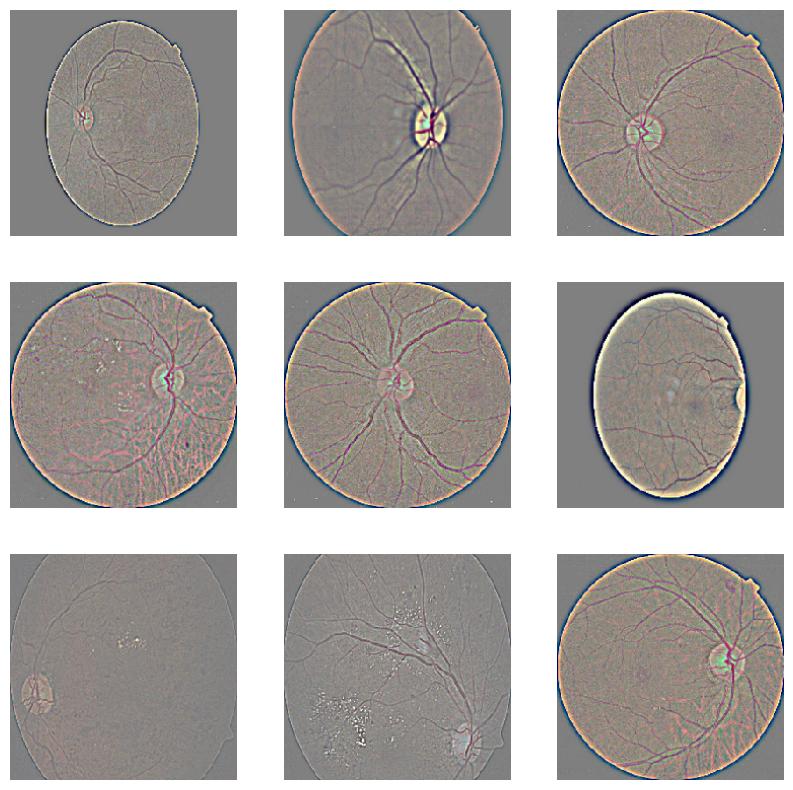

In [11]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()

building CNN Baseline Model

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [13]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(5, activation='softmax')
])

In [15]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 25s 239ms/step - accuracy: 0.5714 - loss: 1.2086 - val_accuracy: 0.6418 - val_loss: 0.9562
Epoch 2/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.6159 - loss: 1.0025 - val_accuracy: 0.6418 - val_loss: 0.9484
Epoch 3/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.6532 - loss: 0.9496 - val_accuracy: 0.6527 - val_loss: 0.8902
Epoch 4/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.6536 - loss: 0.9210 - val_accuracy: 0.6873 - val_loss: 0.8807
Epoch 5/5
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.6645 - loss: 0.8900 - val_accuracy: 0.6800 - val_loss: 0.8412


In [18]:
train_loss, train_accuracy = cnn_model.evaluate(train_data)

print("Training Accuracy:", train_accuracy)

69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.6809 - loss: 0.8095
Training Accuracy: 0.6809090971946716


In [19]:
val_loss, val_accuracy = cnn_model.evaluate(val_data)

print("Validation Accuracy:", val_accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.6800 - loss: 0.8412
Validation Accuracy: 0.6800000071525574


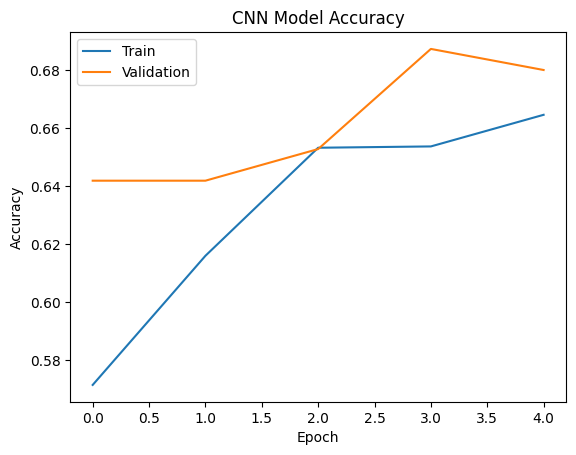

In [20]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

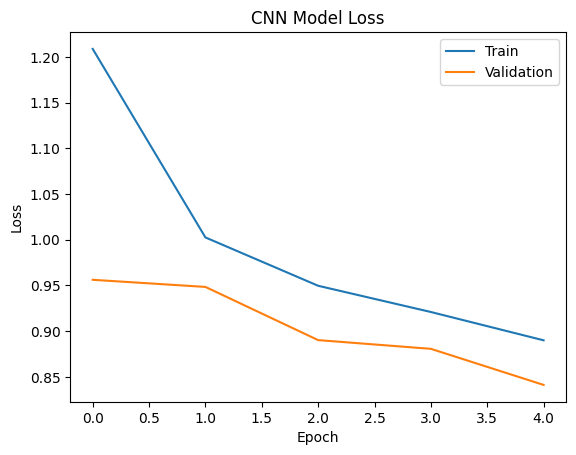

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()